# Question 1 — Line Fitting

Dataset `lines.csv` contains 3 point scatters conforming to 3 lines.  
Columns: **x1, x2, x3** (x-coords of groups 1–3) and **y1, y2, y3** (y-coords of groups 1–3).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Load exactly as specified in the assignment
D = np.genfromtxt('../data/lines.csv', delimiter=',', skip_header=1)
X_cols = D[:, :3]
Y_cols = D[:, 3:]
X_all = X_cols.flatten()
Y_all = Y_cols.flatten()

print('D shape     :', D.shape)
print('X_all shape :', X_all.shape)
print('Y_all shape :', Y_all.shape)
print('\nFirst 5 rows of D:')
print(np.round(D[:5], 4))

D shape     : (100, 6)
X_all shape : (300,)
Y_all shape : (300,)

First 5 rows of D:
[[ -5.3055  -4.0601  -5.2613 -12.6663  -3.7962   3.6917]
 [ -5.5404  -5.0032  -3.9926 -11.0077  -3.9856   4.9   ]
 [ -4.9821  -4.5845  -4.3312 -11.6973  -3.5893   5.0469]
 [ -4.4957  -5.0641  -4.782  -11.978   -3.5971   4.6359]
 [ -4.4422  -4.4114  -4.5675 -12.415   -2.7995   4.7397]]


## Part (a) — Total Least Squares on the First Line

Fit a line using **only the first line's data** (columns x1, y1).  
Total least squares minimises orthogonal (perpendicular) distances, unlike ordinary LS which minimises vertical residuals.

Line in **normal form**: $ax + by = d$ where $(a, b)$ is a unit normal vector.

**Method**: the normal $(a,b)$ is the eigenvector of the scatter matrix $U^TU$ corresponding to the **smallest** eigenvalue — equivalently the **last row of $V^T$** from SVD.

In [2]:
# Extract first line's data
x1 = D[:, 0]
y1 = D[:, 3]
pts1 = np.column_stack((x1, y1))   # shape (N, 2)

# Centre the data
mean1 = np.mean(pts1, axis=0)
U = pts1 - mean1

# SVD of scatter matrix — last row of Vt = eigenvector for smallest eigenvalue
_, _, Vt = np.linalg.svd(U.T @ U)
a, b = Vt[-1, 0], Vt[-1, 1]
d = a * mean1[0] + b * mean1[1]

print('=== Total Least Squares — Line 1 ===')
print(f'  Normal vector : a = {a:.6f},  b = {b:.6f}')
print(f'  Distance term : d = {d:.6f}')
print(f'  Line equation : {a:.4f}·x + {b:.4f}·y = {d:.4f}')

# Mean perpendicular residual (should be small)
residuals = np.abs(a * x1 + b * y1 - d)
print(f'  Mean perp. residual: {residuals.mean():.6f}')

=== Total Least Squares — Line 1 ===
  Normal vector : a = -0.773562,  b = 0.633721
  Distance term : d = -3.794192
  Line equation : -0.7736·x + 0.6337·y = -3.7942
  Mean perp. residual: 0.405888


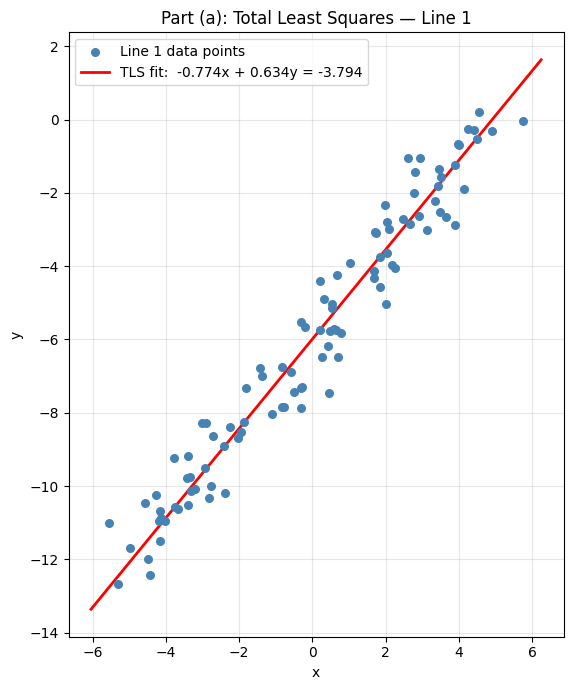

In [3]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(x1, y1, color='steelblue', s=30, zorder=3, label='Line 1 data points')

# Draw fitted line across the data range
x_range = np.array([x1.min() - 0.5, x1.max() + 0.5])
y_range = (d - a * x_range) / b
ax.plot(x_range, y_range, 'r-', linewidth=2, label=f'TLS fit:  {a:.3f}x + {b:.3f}y = {d:.3f}')

ax.set_title('Part (a): Total Least Squares — Line 1')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/p1a_tls.png', dpi=150)
plt.show()

## Part (b) — RANSAC on All Three Lines

Use **all 3×N points** (mixed from all three groups) and apply RANSAC iteratively:  
1. Run RANSAC → find best line + its consensus set (inliers)  
2. Mask out those inliers  
3. Repeat on remaining points → find next line  
4. Repeat once more → find third line

In [4]:
import math

def line_from_two_points(p1, p2):
    """Unit-normal line (a, b, d) passing through p1 and p2."""
    dx, dy = p2[0] - p1[0], p2[1] - p1[1]
    mag = math.sqrt(dx**2 + dy**2)
    a, b = dy / mag, -dx / mag
    d = a * p1[0] + b * p1[1]
    return a, b, d

def perp_distances(pts, a, b, d):
    """Perpendicular distances from each point to line ax+by=d."""
    return np.abs(a * pts[:, 0] + b * pts[:, 1] - d)

def fit_tls(pts):
    """Fit a line to pts using Total Least Squares (SVD)."""
    mean = np.mean(pts, axis=0)
    U = pts - mean
    _, _, Vt = np.linalg.svd(U.T @ U)
    a, b = Vt[-1, 0], Vt[-1, 1]
    d = a * mean[0] + b * mean[1]
    return a, b, d

def ransac_line(pts, t=0.5, max_iter=500):
    """
    RANSAC line fitting.
    Returns (a, b, d, inlier_mask).
    """
    N = len(pts)
    best_model = None
    best_mask  = np.zeros(N, dtype=bool)
    best_count = 0

    for _ in range(max_iter):
        # 1. Sample minimal set (2 points)
        idx = np.random.choice(N, 2, replace=False)
        a, b, d = line_from_two_points(pts[idx[0]], pts[idx[1]])

        # 2. Count inliers
        mask = perp_distances(pts, a, b, d) < t
        if mask.sum() > best_count:
            # 3. Refit using all inliers
            a, b, d = fit_tls(pts[mask])
            mask = perp_distances(pts, a, b, d) < t
            if mask.sum() > best_count:
                best_model = (a, b, d)
                best_mask  = mask
                best_count = mask.sum()

    return (*best_model, best_mask)

In [5]:
np.random.seed(0)

pts_all   = np.column_stack((X_all, Y_all))   # all 3N points mixed
remaining = np.ones(len(pts_all), dtype=bool) # points not yet assigned

found_lines = []   # (a, b, d) for each line
found_masks = []   # global inlier mask for each line

for i in range(3):
    # Work only on unassigned points
    local_pts  = pts_all[remaining]
    local_idx  = np.where(remaining)[0]

    a, b, d, local_mask = ransac_line(local_pts, t=0.5, max_iter=500)

    # Map local inlier mask back to global index space
    global_mask = np.zeros(len(pts_all), dtype=bool)
    global_mask[local_idx[local_mask]] = True

    found_lines.append((a, b, d))
    found_masks.append(global_mask)
    remaining[global_mask] = False   # remove inliers for next round

    print(f'Line {i+1}: a={a:.4f}  b={b:.4f}  d={d:.4f}  |  inliers: {global_mask.sum()}')

print(f'Remaining (unassigned) points: {remaining.sum()}')

Line 1: a=0.4421  b=0.8970  d=1.8812  |  inliers: 83
Line 2: a=-0.7189  b=0.6951  d=0.7267  |  inliers: 66
Line 3: a=-0.7872  b=0.6168  d=-3.7834  |  inliers: 62
Remaining (unassigned) points: 89


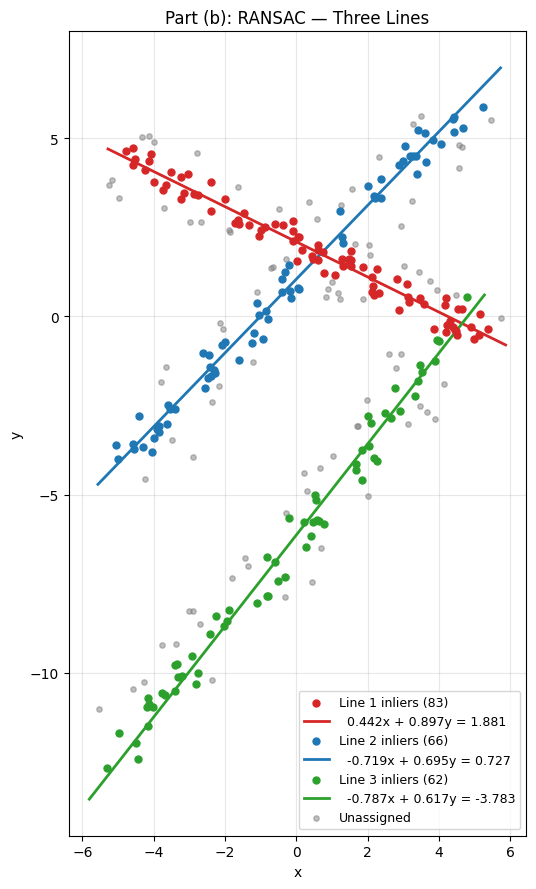

In [6]:
colors = ['tab:red', 'tab:blue', 'tab:green']

fig, ax = plt.subplots(figsize=(9, 9))

for i, ((a, b, d), mask, col) in enumerate(zip(found_lines, found_masks, colors)):
    inlier_pts = pts_all[mask]
    ax.scatter(inlier_pts[:, 0], inlier_pts[:, 1],
               color=col, s=25, zorder=3, label=f'Line {i+1} inliers ({mask.sum()})')
    xs = np.array([inlier_pts[:, 0].min() - 0.5, inlier_pts[:, 0].max() + 0.5])
    ys = (d - a * xs) / b
    ax.plot(xs, ys, color=col, linewidth=2,
            label=f'  {a:.3f}x + {b:.3f}y = {d:.3f}')

# Unassigned points
if remaining.sum() > 0:
    ax.scatter(pts_all[remaining, 0], pts_all[remaining, 1],
               color='gray', s=15, alpha=0.5, zorder=2, label='Unassigned')

ax.set_title('Part (b): RANSAC — Three Lines')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.legend(fontsize=9); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../output/p1b_ransac.png', dpi=150)
plt.show()